In [1]:
from google.colab import files
uploaded = files.upload()

Saving shopify_stock.csv to shopify_stock.csv


In [2]:
import pandas as pd

df = pd.read_csv('/content/shopify_stock.csv')
display(df.head())

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


/tmp/ipykernel_833/936956953.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'])


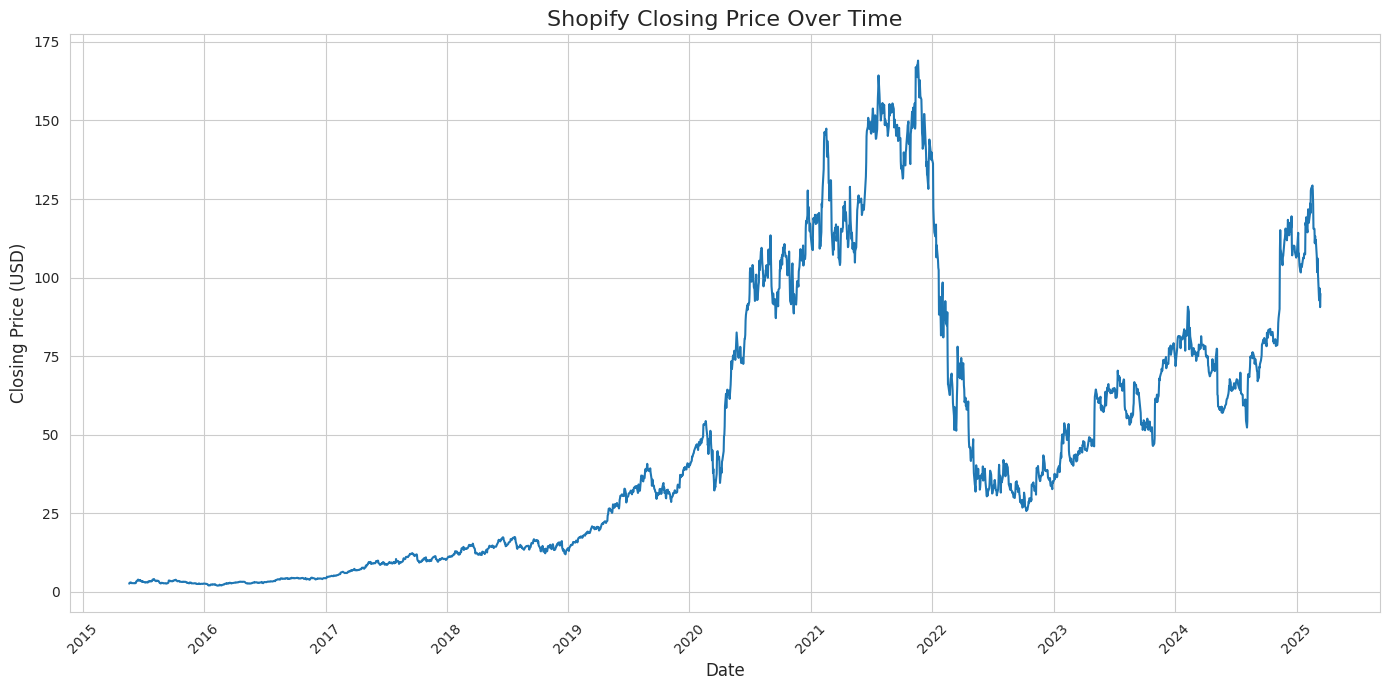

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
df['date'] = pd.to_datetime(df['date'])
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='close', data=df)
plt.title('Shopify Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

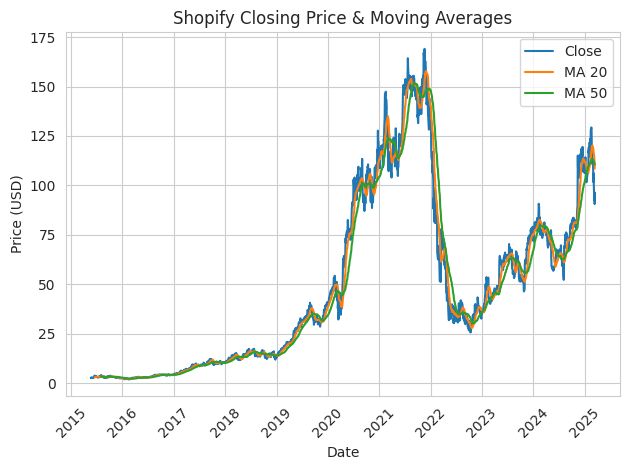

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
df['MA_20'] = df['close'].rolling(20).mean()
df['MA_50'] = df['close'].rolling(50).mean()
sns.lineplot(x='date', y='close', data=df, label='Close')
sns.lineplot(x='date', y='MA_20', data=df, label='MA 20')
sns.lineplot(x='date', y='MA_50', data=df, label='MA 50')
plt.title('Shopify Closing Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df['daily_returns'] = df['close'].pct_change()
display(df.head())

,date,open,high,low,close,adj_close,volume,MA_20,MA_50,daily_returns
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000,NaN,NaN,NaN
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000,NaN,NaN,0.102414
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000,NaN,NaN,0.047333
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000,NaN,NaN,-0.072513
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000,NaN,NaN,-0.001818


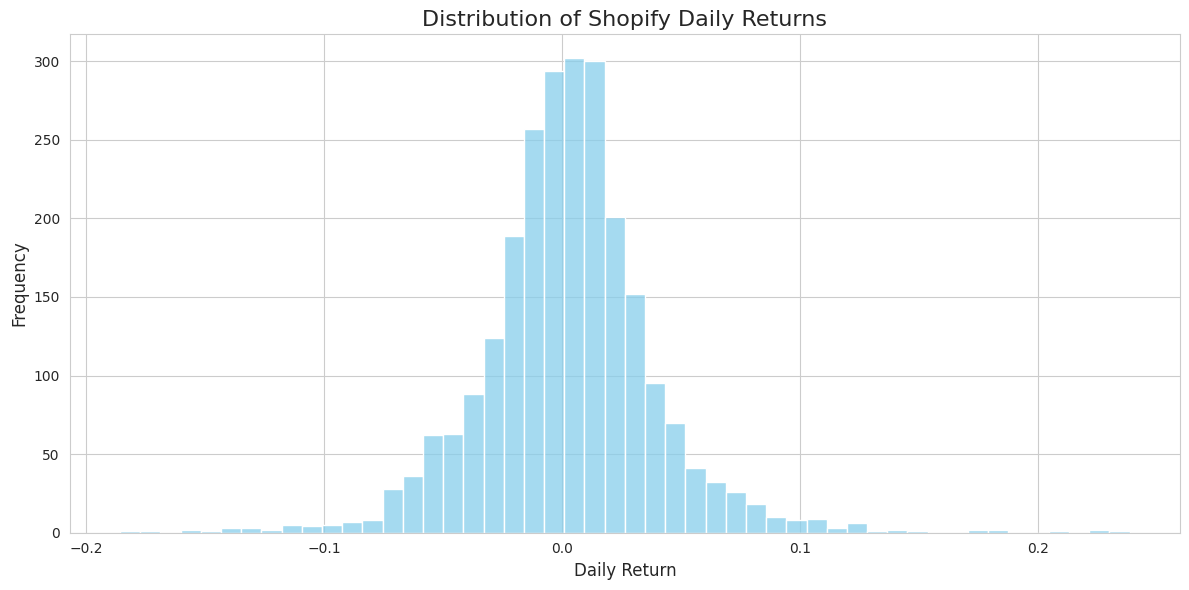

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_returns'].dropna(), bins=50, color='skyblue')
plt.title('Distribution of Shopify Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()